# LSTM para predicción de BIS con pérdida SLD

Esta libreta implementa un modelo LSTM sencillo que recibe dos series de entrada
(propofol y remifentanilo) y predice el valor de BIS.

La función de coste utilizada es **SLD** (*Smooth Label Distribution*), es decir,
una pérdida cuadrática ponderada por la densidad de la distribución de etiquetas.


In [1]:

# =============================================================================
# IMPORTACIONES
# =============================================================================
import math
import time
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

# =============================================================================
# CONFIGURACIÓN GENERAL
# =============================================================================
TASA_APRENDIZAJE = 1e-4
EPOCAS = 25
TAMANIYO_LOTE = 128
PASO_DECAIMIENTO_LR = 6
GAMMA_LR = 0.2
PACIENCIA = 8

UNIDADES_LSTM = 64
NUM_CAPAS_LSTM = 2
DROPOUT = 0.25

ANCHO_BANDA_SLD = 12.0
NUM_INTERVALOS_SLD = 101

RUTA_PT_ENTRENAMIENTO = r"C:\Users\yordi\Desktop\dataset_entrenamiento.pt"
RUTA_PT_VALIDACION    = r"C:\Users\yordi\Desktop\dataset_validacion.pt"
RUTA_PT_PRUEBA        = r"C:\Users\yordi\Desktop\dataset_prueba.pt"
RUTA_MODELO_SALIDA    = r"C:\Users\yordi\Desktop\modelo_lstm_bis_sld.pt"

# =============================================================================
# DISPOSITIVO
# =============================================================================
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Dispositivo: {dispositivo}")
if dispositivo.type == "cuda":
    print(f"[INFO] GPU: {torch.cuda.get_device_name(0)}")


[INFO] Dispositivo: cuda
[INFO] GPU: NVIDIA GeForce RTX 5060


In [2]:

# =============================================================================
# DATASET
# =============================================================================
class DatasetBISLSTM(Dataset):
    """
    Carga un archivo .pt con las claves generadas por el preprocesamiento:
        - infusiones  : (N, 2, T)
        - etiquetas   : (N,)

    Para este modelo únicamente se utilizan las dos series de infusión.
    """

    def __init__(self, ruta_pt: str):
        datos = torch.load(ruta_pt, map_location="cpu", weights_only=True)

        if "infusiones" not in datos or "etiquetas" not in datos:
            raise KeyError(
                "El archivo .pt debe contener, como mínimo, las claves "
                "'infusiones' y 'etiquetas'."
            )

        self.infusiones = datos["infusiones"].to(torch.float32)
        self.etiquetas = datos["etiquetas"].to(torch.float32)

        # Se acepta la convención (N, 2, T) o (N, T, 2).
        if self.infusiones.ndim != 3:
            raise ValueError("La variable 'infusiones' debe tener 3 dimensiones.")

    def __len__(self):
        return len(self.etiquetas)

    def __getitem__(self, idx):
        x = self.infusiones[idx]
        y = self.etiquetas[idx]

        # Se normaliza la forma a (T, 2) para alimentar la LSTM.
        if x.shape[0] == 2:
            x = x.permute(1, 0)  # (2, T) -> (T, 2)
        elif x.shape[-1] == 2:
            x = x  # ya está en (T, 2)
        else:
            raise ValueError(
                "No fue posible interpretar la forma de 'infusiones'. "
                "Se esperaba (2, T) o (T, 2)."
            )

        return x, y


# =============================================================================
# CARGA DE DATOS
# =============================================================================
ds_ent = DatasetBISLSTM(RUTA_PT_ENTRENAMIENTO)
ds_val = DatasetBISLSTM(RUTA_PT_VALIDACION)
ds_pru = DatasetBISLSTM(RUTA_PT_PRUEBA)

dl_ent = DataLoader(ds_ent, batch_size=TAMANIYO_LOTE, shuffle=True)
dl_val = DataLoader(ds_val, batch_size=TAMANIYO_LOTE, shuffle=False)
dl_pru = DataLoader(ds_pru, batch_size=TAMANIYO_LOTE, shuffle=False)

print(f"[INFO] Muestras entrenamiento: {len(ds_ent):,}")
print(f"[INFO] Muestras validación    : {len(ds_val):,}")
print(f"[INFO] Muestras prueba        : {len(ds_pru):,}")


[INFO] Muestras entrenamiento: 501,672
[INFO] Muestras validación    : 137,332
[INFO] Muestras prueba        : 38,977


In [3]:

# =============================================================================
# PÉRDIDA SLD
# =============================================================================
class PerdidaSLD(nn.Module):
    """
    Implementa una pérdida tipo Smooth Label Distribution.

    La idea consiste en asignar mayor peso a las regiones menos frecuentes de
    la distribución de etiquetas, de forma que el modelo no se concentre
    exclusivamente en los valores dominantes.
    """

    def __init__(self, etiquetas: np.ndarray,
                 ancho_banda: float = ANCHO_BANDA_SLD,
                 num_intervalos: int = NUM_INTERVALOS_SLD):
        super().__init__()

        etiquetas = np.asarray(etiquetas, dtype=np.float32)

        conteos, bordes = np.histogram(
            etiquetas, bins=num_intervalos, range=(0.0, 100.0)
        )
        centros = 0.5 * (bordes[:-1] + bordes[1:])

        densidad = gaussian_filter1d(
            conteos.astype(np.float32) + 1e-6, sigma=ancho_banda
        )

        pesos = 1.0 / densidad
        pesos /= pesos.max()

        self.register_buffer("centros", torch.tensor(centros, dtype=torch.float32))
        self.register_buffer("pesos_inv", torch.tensor(pesos, dtype=torch.float32))

    def forward(self, pred: torch.Tensor, etiq: torch.Tensor) -> torch.Tensor:
        """
        pred : (B,)
        etiq : (B,)
        """
        # Se localiza el intervalo más cercano para cada etiqueta.
        idx = (etiq.unsqueeze(1) - self.centros.unsqueeze(0)).abs().argmin(dim=1)
        pesos = self.pesos_inv[idx]
        return (pesos * (pred - etiq) ** 2).mean()


fn_sld = PerdidaSLD(ds_ent.etiquetas.numpy()).to(dispositivo)
fn_mse = nn.MSELoss()
print("[INFO] Pérdida SLD construida correctamente.")


[INFO] Pérdida SLD construida correctamente.


In [4]:

# =============================================================================
# MODELO LSTM
# =============================================================================
class LSTMBIS(nn.Module):
    """
    Modelo de predicción de BIS basado en dos LSTM independientes.

    Entrada:
        propofol      : (B, T, 1)
        remifentanilo : (B, T, 1)

    Salida:
        bis_pred      : (B,)
    """

    def __init__(self,
                 unidades_lstm: int = UNIDADES_LSTM,
                 num_capas: int = NUM_CAPAS_LSTM,
                 dropout: float = DROPOUT):
        super().__init__()

        self.lstm_propofol = nn.LSTM(
            input_size=1,
            hidden_size=unidades_lstm,
            num_layers=num_capas,
            batch_first=True,
            dropout=dropout if num_capas > 1 else 0.0
        )

        self.lstm_remifentanilo = nn.LSTM(
            input_size=1,
            hidden_size=unidades_lstm,
            num_layers=num_capas,
            batch_first=True,
            dropout=dropout if num_capas > 1 else 0.0
        )

        self.regresor = nn.Sequential(
            nn.Linear(unidades_lstm * 2, unidades_lstm),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(unidades_lstm, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x : (B, T, 2)
        """
        propofol = x[:, :, 0:1]
        remifent  = x[:, :, 1:2]

        _, (h_p, _) = self.lstm_propofol(propofol)
        _, (h_r, _) = self.lstm_remifentanilo(remifent)

        # Se toma el último estado oculto de la última capa.
        h_p = h_p[-1]
        h_r = h_r[-1]

        h = torch.cat([h_p, h_r], dim=1)
        salida = self.regresor(h).squeeze(-1)
        return salida


modelo = LSTMBIS().to(dispositivo)
n_params = sum(p.numel() for p in modelo.parameters())
print(f"[INFO] Parámetros del modelo: {n_params:,}")


[INFO] Parámetros del modelo: 109,185


In [5]:

# =============================================================================
# FUNCIONES DE ENTRENAMIENTO
# =============================================================================
def entrenar_epoca(modelo, cargador, optimizador, fn_sld):
    modelo.train()
    total = 0.0

    for x, y in cargador:
        x = x.to(dispositivo, non_blocking=True)
        y = y.to(dispositivo, non_blocking=True)

        optimizador.zero_grad(set_to_none=True)
        pred = modelo(x)
        perdida = fn_sld(pred, y)
        perdida.backward()
        optimizador.step()

        total += perdida.item()

    return total / len(cargador)


@torch.no_grad()
def evaluar(modelo, cargador, fn_sld, fn_mse):
    modelo.eval()
    total_sld = 0.0
    total_mse = 0.0

    for x, y in cargador:
        x = x.to(dispositivo, non_blocking=True)
        y = y.to(dispositivo, non_blocking=True)

        pred = modelo(x)
        total_sld += fn_sld(pred, y).item()
        total_mse += fn_mse(pred, y).item()

    return total_sld / len(cargador), total_mse / len(cargador)


In [6]:

# =============================================================================
# ENTRENAMIENTO
# =============================================================================
optimizador = torch.optim.Adam(modelo.parameters(), lr=TASA_APRENDIZAJE, weight_decay=5e-4)
planificador = torch.optim.lr_scheduler.StepLR(
    optimizador,
    step_size=PASO_DECAIMIENTO_LR,
    gamma=GAMMA_LR
)
fn_mse = nn.MSELoss()

hist_ent = []
hist_val = []
mejor_val = float("inf")
epocas_sin_mejora = 0

print("\n" + "=" * 60)
print("ENTRENAMIENTO")
print("=" * 60)

for epoca in range(1, EPOCAS + 1):
    t0 = time.time()

    perdida_ent = entrenar_epoca(modelo, dl_ent, optimizador, fn_sld)
    perdida_val_sld, perdida_val_mse = evaluar(modelo, dl_val, fn_sld, fn_mse)
    planificador.step()

    hist_ent.append(perdida_ent)
    hist_val.append(perdida_val_sld)

    dt = time.time() - t0
    print(
        f"Época {epoca:3d}/{EPOCAS} | "
        f"SLD ent: {perdida_ent:.4f} | "
        f"SLD val: {perdida_val_sld:.4f} | "
        f"MSE val: {perdida_val_mse:.4f} | "
        f"tiempo: {dt:.1f}s"
    )

    # Guardado del mejor modelo según validación.
    if perdida_val_sld < mejor_val:
        mejor_val = perdida_val_sld
        epocas_sin_mejora = 0
        torch.save(modelo.state_dict(), RUTA_MODELO_SALIDA)
        print("  [INFO] Modelo guardado.")
    else:
        epocas_sin_mejora += 1

    # Criterio sencillo de parada temprana.
    if epocas_sin_mejora >= PACIENCIA:
        print("  [INFO] Parada temprana activada.")
        break

print("\n[INFO] Entrenamiento finalizado.")



ENTRENAMIENTO
Época   1/25 | SLD ent: 36.8005 | SLD val: 20.5530 | MSE val: 306.5360 | tiempo: 26.0s
  [INFO] Modelo guardado.
Época   2/25 | SLD ent: 20.0051 | SLD val: 13.6521 | MSE val: 240.3904 | tiempo: 26.6s
  [INFO] Modelo guardado.
Época   3/25 | SLD ent: 15.2114 | SLD val: 10.9484 | MSE val: 239.3784 | tiempo: 26.7s
  [INFO] Modelo guardado.
Época   4/25 | SLD ent: 12.0245 | SLD val: 8.5840 | MSE val: 173.7963 | tiempo: 26.2s
  [INFO] Modelo guardado.
Época   5/25 | SLD ent: 10.3780 | SLD val: 7.3372 | MSE val: 126.0320 | tiempo: 25.9s
  [INFO] Modelo guardado.
Época   6/25 | SLD ent: 10.5944 | SLD val: 7.2315 | MSE val: 142.7105 | tiempo: 26.2s
  [INFO] Modelo guardado.
Época   7/25 | SLD ent: 9.2291 | SLD val: 6.8914 | MSE val: 133.9201 | tiempo: 26.2s
  [INFO] Modelo guardado.
Época   8/25 | SLD ent: 9.1211 | SLD val: 6.8359 | MSE val: 132.5411 | tiempo: 26.4s
  [INFO] Modelo guardado.
Época   9/25 | SLD ent: 8.9588 | SLD val: 6.7946 | MSE val: 133.3697 | tiempo: 26.5s
  [

In [7]:

# =============================================================================
# EVALUACIÓN FINAL EN PRUEBA
# =============================================================================
modelo.load_state_dict(torch.load(RUTA_MODELO_SALIDA, map_location=dispositivo, weights_only=True))
perdida_prueba_sld, perdida_prueba_mse = evaluar(modelo, dl_pru, fn_sld, fn_mse)

print("=" * 60)
print(f"SLD prueba : {perdida_prueba_sld:.4f}")
print(f"MSE prueba : {perdida_prueba_mse:.4f}")
print("=" * 60)


SLD prueba : 7.7671
MSE prueba : 142.9422


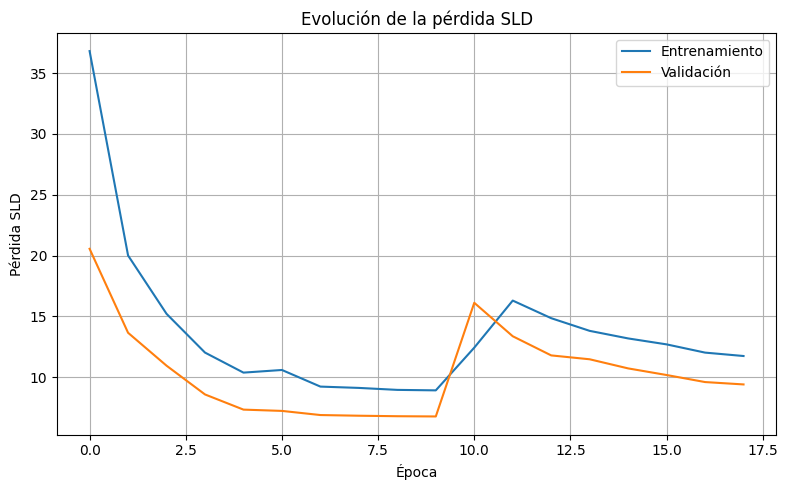

In [8]:

# =============================================================================
# GRÁFICA DE ENTRENAMIENTO
# =============================================================================
plt.figure(figsize=(8, 5))
plt.plot(hist_ent, label="Entrenamiento")
plt.plot(hist_val, label="Validación")
plt.xlabel("Época")
plt.ylabel("Pérdida SLD")
plt.title("Evolución de la pérdida SLD")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
